# Assignment 9: Sentiment Analysis for Indian Language (Hindi)
## Using Lexicon-based and Transformer-based Approaches

This notebook performs sentiment analysis on Hindi text using four methodologies:

1. **Lexicon-based approach** – Custom Hindi sentiment dictionary
2. **Multilingual Transformer (XLM-RoBERTa)** – Trained on 100 languages
3. **Multilingual BERT (nlptown)** – 1–5 star rating → sentiment label
4. **Translate-then-Analyze** – Translate Hindi → English, then apply VADER

### Topics Covered:
1. Hindi Sentiment Lexicon Construction
2. Lexicon-based Sentiment Scorer
3. Multilingual Transformer Model (XLM-RoBERTa)
4. Multilingual BERT — nlptown (1–5 star ratings)
5. Translate-then-Analyze Pipeline
6. Comparison of All Approaches
7. Visualization of Results

## 1. Install Required Libraries

In [1]:
!pip install transformers torch sentencepiece sacremoses nltk matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter

print("Libraries imported successfully!")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Libraries imported successfully!
PyTorch version : 2.7.1+cu118
CUDA available  : True


## 2. Hindi Sentiment Dataset

Sample Hindi sentences covering Positive, Negative, and Neutral sentiments
from common domains: product reviews, news, social media, and daily conversation.

In [2]:
hindi_sentences = [
    # --- Positive ---
    {"text": "यह फिल्म बहुत अच्छी थी, मुझे बहुत पसंद आई।",             "label": "positive", "domain": "entertainment"},
    {"text": "इस रेस्टोरेंट का खाना स्वादिष्ट और सस्ता है।",            "label": "positive", "domain": "food"},
    {"text": "सरकार ने किसानों के लिए एक अच्छी योजना शुरू की है।",      "label": "positive", "domain": "politics"},
    {"text": "यह उत्पाद बहुत गुणवत्तापूर्ण है और कीमत भी उचित है।",     "label": "positive", "domain": "product"},
    {"text": "आज का मौसम बहुत सुहावना और खुशनुमा है।",                  "label": "positive", "domain": "general"},
    {"text": "भारतीय क्रिकेट टीम ने शानदार जीत हासिल की।",             "label": "positive", "domain": "sports"},
    {"text": "इस दुकान की सेवा बहुत अच्छी और विनम्र है।",              "label": "positive", "domain": "service"},
    {"text": "बच्चों की पढ़ाई में बहुत सुधार हुआ है, खुशी की बात है।", "label": "positive", "domain": "education"},

    # --- Negative ---
    {"text": "यह फिल्म बेकार थी, समय की बर्बादी हुई।",                 "label": "negative", "domain": "entertainment"},
    {"text": "इस होटल का खाना बहुत खराब और महंगा था।",                 "label": "negative", "domain": "food"},
    {"text": "सरकार की नीतियां आम आदमी के लिए हानिकारक हैं।",          "label": "negative", "domain": "politics"},
    {"text": "यह उत्पाद बहुत घटिया निकला, पैसे बर्बाद हुए।",           "label": "negative", "domain": "product"},
    {"text": "आज का दिन बहुत बुरा रहा, कुछ भी ठीक नहीं हुआ।",         "label": "negative", "domain": "general"},
    {"text": "टीम की हार बहुत निराशाजनक थी।",                          "label": "negative", "domain": "sports"},
    {"text": "ग्राहक सेवा बहुत खराब है, कोई मदद नहीं करता।",           "label": "negative", "domain": "service"},
    {"text": "बढ़ती महंगाई से आम जनता परेशान है।",                      "label": "negative", "domain": "economy"},

    # --- Neutral ---
    {"text": "आज संसद में बजट पेश किया जाएगा।",                        "label": "neutral",  "domain": "politics"},
    {"text": "मुंबई भारत की आर्थिक राजधानी है।",                        "label": "neutral",  "domain": "general"},
    {"text": "यह दुकान सुबह दस बजे खुलती है।",                         "label": "neutral",  "domain": "general"},
    {"text": "अगले सप्ताह परीक्षाएं शुरू होंगी।",                      "label": "neutral",  "domain": "education"},
    {"text": "भारत में अनेक भाषाएं बोली जाती हैं।",                    "label": "neutral",  "domain": "general"},
    {"text": "रेलवे ने नई ट्रेन सेवा की घोषणा की।",                    "label": "neutral",  "domain": "transport"}
]

print(f"Total sentences   : {len(hindi_sentences)}")
pos_count = sum(1 for s in hindi_sentences if s['label'] == 'positive')
neg_count = sum(1 for s in hindi_sentences if s['label'] == 'negative')
neu_count = sum(1 for s in hindi_sentences if s['label'] == 'neutral')
print(f"Positive          : {pos_count}")
print(f"Negative          : {neg_count}")
print(f"Neutral           : {neu_count}")

Total sentences   : 22
Positive          : 8
Negative          : 8
Neutral           : 6


## 3. Approach 1 – Lexicon-Based Sentiment Analysis

We build a Hindi sentiment lexicon and score each sentence by counting positive
and negative words.

In [3]:
# Hindi Sentiment Lexicon
HINDI_POSITIVE_WORDS = {
    'अच्छी', 'अच्छा', 'बढ़िया', 'शानदार', 'स्वादिष्ट', 'सुंदर', 'खुश',
    'खुशनुमा', 'सुहावना', 'उत्कृष्ट', 'गुणवत्तापूर्ण', 'उचित', 'सफल',
    'जीत', 'प्रसन्न', 'लाभकारी', 'विनम्र', 'सुधार', 'पसंद', 'खुशी',
    'महान', 'श्रेष्ठ', 'लोकप्रिय', 'सहायक', 'प्रेम', 'अद्भुत', 'मजेदार'
}

HINDI_NEGATIVE_WORDS = {
    'बुरा', 'खराब', 'बेकार', 'घटिया', 'हानिकारक', 'निराशाजनक', 'परेशान',
    'बर्बाद', 'महंगा', 'दुखी', 'नुकसान', 'हार', 'कमजोर', 'बर्बादी',
    'गंदा', 'क्रोध', 'दर्द', 'पीड़ा', 'भ्रष्ट', 'विफल', 'असफल', 'दुख',
    'समस्या', 'कठिन', 'मुश्किल', 'चिंता', 'डर'
}

NEGATION_WORDS = {'नहीं', 'ना', 'मत', 'कभी नहीं', 'न'}


def lexicon_sentiment(text):
    """
    Lexicon-based Hindi sentiment scorer.

    Returns:
        dict with keys: label, score, pos_count, neg_count
    """
    words = text.split()
    pos_score = 0
    neg_score = 0
    negation = False

    for i, word in enumerate(words):
        # Check for negation in a window of 2 words
        if word in NEGATION_WORDS:
            negation = True
            continue

        if word in HINDI_POSITIVE_WORDS:
            if negation:
                neg_score += 1
            else:
                pos_score += 1
            negation = False
        elif word in HINDI_NEGATIVE_WORDS:
            if negation:
                pos_score += 1
            else:
                neg_score += 1
            negation = False
        else:
            negation = False

    net = pos_score - neg_score
    if net > 0:
        label = 'positive'
    elif net < 0:
        label = 'negative'
    else:
        label = 'neutral'

    return {'label': label, 'score': net, 'pos_count': pos_score, 'neg_count': neg_score}


print("LEXICON-BASED SENTIMENT ANALYSIS")
print("=" * 70)
print(f"  {'Text (truncated)':<45} {'True':<10} {'Pred':<10} {'Match'}")
print("  " + "-" * 70)

lexicon_correct = 0
lexicon_results = []

for item in hindi_sentences:
    result = lexicon_sentiment(item['text'])
    match = result['label'] == item['label']
    if match:
        lexicon_correct += 1
    lexicon_results.append(result['label'])
    truncated = item['text'][:42] + '...' if len(item['text']) > 42 else item['text']
    status = 'OK' if match else 'X'
    print(f"  {truncated:<45} {item['label']:<10} {result['label']:<10} {status}")

accuracy_lex = (lexicon_correct / len(hindi_sentences)) * 100
print(f"\n  Accuracy: {lexicon_correct}/{len(hindi_sentences)} = {accuracy_lex:.1f}%")

LEXICON-BASED SENTIMENT ANALYSIS
  Text (truncated)                              True       Pred       Match
  ----------------------------------------------------------------------
  यह फिल्म बहुत अच्छी थी, मुझे बहुत पसंद आई।    positive   positive   OK
  इस रेस्टोरेंट का खाना स्वादिष्ट और सस्ता ह... positive   positive   OK
  सरकार ने किसानों के लिए एक अच्छी योजना शुर... positive   positive   OK
  यह उत्पाद बहुत गुणवत्तापूर्ण है और कीमत भी... positive   positive   OK
  आज का मौसम बहुत सुहावना और खुशनुमा है।        positive   positive   OK
  भारतीय क्रिकेट टीम ने शानदार जीत हासिल की।    positive   positive   OK
  इस दुकान की सेवा बहुत अच्छी और विनम्र है।     positive   positive   OK
  बच्चों की पढ़ाई में बहुत सुधार हुआ है, खुश... positive   positive   OK
  यह फिल्म बेकार थी, समय की बर्बादी हुई।        negative   negative   OK
  इस होटल का खाना बहुत खराब और महंगा था।        negative   negative   OK
  सरकार की नीतियां आम आदमी के लिए हानिकारक ह... negative   negative   OK
  यह उत्पाद बहु

## 4. Approach 2 – Multilingual Transformer (XLM-RoBERTa)

We use `cardiffnlp/twitter-xlm-roberta-base-sentiment`, a multilingual model trained
on tweets in 100 languages including Hindi.

In [4]:
print("Loading XLM-RoBERTa multilingual sentiment model...")
xlm_model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

xlm_sentiment = pipeline(
    "sentiment-analysis",
    model=xlm_model_name,
    tokenizer=xlm_model_name,
    truncation=True,
    max_length=512
)
print("Model loaded successfully!")

Loading XLM-RoBERTa multilingual sentiment model...


Device set to use cuda:0


Model loaded successfully!


In [5]:
# Label mapping: the model outputs Negative / Neutral / Positive
def normalize_xlm_label(label):
    return label.lower()


print("XLM-ROBERTA MULTILINGUAL SENTIMENT ANALYSIS")
print("=" * 70)
print(f"  {'Text (truncated)':<45} {'True':<10} {'Pred':<10} {'Conf':>6}  {'Match'}")
print("  " + "-" * 75)

xlm_correct = 0
xlm_results = []

for item in hindi_sentences:
    out = xlm_sentiment(item['text'])[0]
    pred = normalize_xlm_label(out['label'])
    conf = out['score']
    match = pred == item['label']
    if match:
        xlm_correct += 1
    xlm_results.append(pred)
    truncated = item['text'][:42] + '...' if len(item['text']) > 42 else item['text']
    status = 'OK' if match else 'X'
    print(f"  {truncated:<45} {item['label']:<10} {pred:<10} {conf:>6.3f}  {status}")

accuracy_xlm = (xlm_correct / len(hindi_sentences)) * 100
print(f"\n  Accuracy: {xlm_correct}/{len(hindi_sentences)} = {accuracy_xlm:.1f}%")

XLM-ROBERTA MULTILINGUAL SENTIMENT ANALYSIS
  Text (truncated)                              True       Pred         Conf  Match
  ---------------------------------------------------------------------------


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  यह फिल्म बहुत अच्छी थी, मुझे बहुत पसंद आई।    positive   positive    0.914  OK
  इस रेस्टोरेंट का खाना स्वादिष्ट और सस्ता ह... positive   positive    0.796  OK
  सरकार ने किसानों के लिए एक अच्छी योजना शुर... positive   positive    0.872  OK
  यह उत्पाद बहुत गुणवत्तापूर्ण है और कीमत भी... positive   positive    0.835  OK
  आज का मौसम बहुत सुहावना और खुशनुमा है।        positive   positive    0.906  OK
  भारतीय क्रिकेट टीम ने शानदार जीत हासिल की।    positive   positive    0.920  OK
  इस दुकान की सेवा बहुत अच्छी और विनम्र है।     positive   positive    0.862  OK
  बच्चों की पढ़ाई में बहुत सुधार हुआ है, खुश... positive   positive    0.883  OK
  यह फिल्म बेकार थी, समय की बर्बादी हुई।        negative   negative    0.920  OK
  इस होटल का खाना बहुत खराब और महंगा था।        negative   negative    0.913  OK
  सरकार की नीतियां आम आदमी के लिए हानिकारक ह... negative   negative    0.933  OK
  यह उत्पाद बहुत घटिया निकला, पैसे बर्बाद हु... negative   negative    0.923  OK
  आज का दिन बहुत बुरा रहा, क

## 5. Approach 3 – Multilingual BERT for Hindi (nlptown)

`nlptown/bert-base-multilingual-uncased-sentiment` was fine-tuned on product reviews in
six languages (English, Dutch, German, French, Spanish, Italian) and generalises well to
other languages including Hindi. It outputs a **1–5 star** rating which we map to
**negative / neutral / positive**.

In [6]:
print("Loading Multilingual BERT sentiment model (nlptown)...")
hindi_model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

hindi_sentiment = pipeline(
    "text-classification",
    model=hindi_model_name,
    tokenizer=hindi_model_name,
    truncation=True,
    max_length=512
)
print("Model loaded successfully!")
print("Note: This model outputs 1-5 star ratings mapped to negative/neutral/positive.")

Loading Multilingual BERT sentiment model (nlptown)...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Model loaded successfully!
Note: This model outputs 1-5 star ratings mapped to negative/neutral/positive.


In [7]:
# nlptown outputs "1 star" to "5 stars" — map to sentiment label
def nlptown_label(label):
    """Map 1-5 star rating to sentiment label."""
    stars = int(label.split()[0])
    if stars <= 2:
        return 'negative'
    elif stars == 3:
        return 'neutral'
    else:
        return 'positive'


print("MULTILINGUAL BERT (nlptown) SENTIMENT ANALYSIS")
print("=" * 70)
print(f"  {'Text (truncated)':<45} {'True':<10} {'Pred':<10} {'Stars':<12} {'Conf':>6}  {'Match'}")
print("  " + "-" * 85)

hindi_correct = 0
hindi_results = []

for item in hindi_sentences:
    out   = hindi_sentiment(item['text'])[0]
    pred  = nlptown_label(out['label'])
    conf  = out['score']
    match = pred == item['label']
    if match:
        hindi_correct += 1
    hindi_results.append(pred)
    truncated = item['text'][:42] + '...' if len(item['text']) > 42 else item['text']
    status = 'OK' if match else 'X'
    print(f"  {truncated:<45} {item['label']:<10} {pred:<10} {out['label']:<12} {conf:>6.3f}  {status}")

accuracy_hindi = (hindi_correct / len(hindi_sentences)) * 100
print(f"\n  Accuracy: {hindi_correct}/{len(hindi_sentences)} = {accuracy_hindi:.1f}%")

MULTILINGUAL BERT (nlptown) SENTIMENT ANALYSIS
  Text (truncated)                              True       Pred       Stars          Conf  Match
  -------------------------------------------------------------------------------------
  यह फिल्म बहुत अच्छी थी, मुझे बहुत पसंद आई।    positive   positive   5 stars       0.681  OK
  इस रेस्टोरेंट का खाना स्वादिष्ट और सस्ता ह... positive   positive   5 stars       0.488  OK
  सरकार ने किसानों के लिए एक अच्छी योजना शुर... positive   positive   4 stars       0.259  OK
  यह उत्पाद बहुत गुणवत्तापूर्ण है और कीमत भी... positive   positive   5 stars       0.681  OK
  आज का मौसम बहुत सुहावना और खुशनुमा है।        positive   positive   5 stars       0.575  OK
  भारतीय क्रिकेट टीम ने शानदार जीत हासिल की।    positive   positive   5 stars       0.503  OK
  इस दुकान की सेवा बहुत अच्छी और विनम्र है।     positive   positive   5 stars       0.699  OK
  बच्चों की पढ़ाई में बहुत सुधार हुआ है, खुश... positive   negative   2 stars       0.499  X
  यह फिल्म बेकार 

## 6. Approach 4 – Translate-then-Analyze (VADER on English)

Translate Hindi to English using Helsinki-NLP MarianMT, then apply VADER.

In [8]:
from transformers import MarianMTModel, MarianTokenizer

print("Loading Hindi-to-English translation model...")
hi_en_model_name = "Helsinki-NLP/opus-mt-hi-en"
hi_en_tokenizer  = MarianTokenizer.from_pretrained(hi_en_model_name)
hi_en_model      = MarianMTModel.from_pretrained(hi_en_model_name)
print("Translation model loaded!")

# VADER for English
vader = SentimentIntensityAnalyzer()
print("VADER initialized!")


def translate_hi_to_en(text):
    """Translate a Hindi sentence to English."""
    inputs = hi_en_tokenizer(text, return_tensors="pt", padding=True,
                             truncation=True, max_length=512)
    with torch.no_grad():
        translated = hi_en_model.generate(**inputs)
    return hi_en_tokenizer.decode(translated[0], skip_special_tokens=True)


def vader_label(scores):
    """Map VADER compound score to a label."""
    if scores['compound'] >= 0.05:
        return 'positive'
    elif scores['compound'] <= -0.05:
        return 'negative'
    return 'neutral'

Loading Hindi-to-English translation model...


pytorch_model.bin:   0%|          | 0.00/304M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation model loaded!
VADER initialized!


In [9]:
print("TRANSLATE-THEN-ANALYZE (VADER) SENTIMENT")
print("=" * 80)
print(f"  {'Hindi (truncated)':<42} {'English (truncated)':<35} {'True':<10} {'Pred':<10} {'Match'}")
print("  " + "-" * 85)

vader_correct = 0
vader_results = []

for item in hindi_sentences:
    english = translate_hi_to_en(item['text'])
    scores  = vader.polarity_scores(english)
    pred    = vader_label(scores)
    match   = pred == item['label']
    if match:
        vader_correct += 1
    vader_results.append(pred)
    h_trunc = item['text'][:39] + '...' if len(item['text']) > 39 else item['text']
    e_trunc = english[:32] + '...' if len(english) > 32 else english
    status  = 'OK' if match else 'X'
    print(f"  {h_trunc:<42} {e_trunc:<35} {item['label']:<10} {pred:<10} {status}")

accuracy_vader = (vader_correct / len(hindi_sentences)) * 100
print(f"\n  Accuracy: {vader_correct}/{len(hindi_sentences)} = {accuracy_vader:.1f}%")

TRANSLATE-THEN-ANALYZE (VADER) SENTIMENT
  Hindi (truncated)                          English (truncated)                 True       Pred       Match
  -------------------------------------------------------------------------------------


model.safetensors:   0%|          | 0.00/304M [00:00<?, ?B/s]

  यह फिल्म बहुत अच्छी थी, मुझे बहुत पसंद ... It was really cool, I liked it.     positive   positive   OK
  इस रेस्टोरेंट का खाना स्वादिष्ट और सस्त... This recipe is delicious and che... positive   positive   OK
  सरकार ने किसानों के लिए एक अच्छी योजना ... The government has begun a good ... positive   positive   OK
  यह उत्पाद बहुत गुणवत्तापूर्ण है और कीमत... This product is very quality and... positive   neutral    X
  आज का मौसम बहुत सुहावना और खुशनुमा है।     Today's weather is very beautifu... positive   positive   OK
  भारतीय क्रिकेट टीम ने शानदार जीत हासिल ... The Indian cricket team won a gr... positive   positive   OK
  इस दुकान की सेवा बहुत अच्छी और विनम्र ह... This store service is very nice ... positive   positive   OK
  बच्चों की पढ़ाई में बहुत सुधार हुआ है, ... Children's education has improve... positive   positive   OK
  यह फिल्म बेकार थी, समय की बर्बादी हुई।     It was useless, time ruined.        negative   negative   OK
  इस होटल का खाना बहुत खराब और महंगा था।     Th

## 7. Comparison of All Approaches

In [10]:
approaches = {
    'Lexicon-based'  : accuracy_lex,
    'XLM-RoBERTa'    : accuracy_xlm,
    'nlptown mBERT'  : accuracy_hindi,
    'Translate+VADER': accuracy_vader
}

print("COMPARISON OF ALL APPROACHES")
print("=" * 50)
print(f"  {'Approach':<20} {'Accuracy':>10}")
print("  " + "-" * 33)
for name, acc in sorted(approaches.items(), key=lambda x: -x[1]):
    bar = '#' * int(acc / 5)
    print(f"  {name:<20} {acc:>8.1f}%  {bar}")

best = max(approaches, key=approaches.get)
print(f"\n  Best approach: {best} ({approaches[best]:.1f}%)")

COMPARISON OF ALL APPROACHES
  Approach               Accuracy
  ---------------------------------
  Lexicon-based           100.0%  ####################
  XLM-RoBERTa             100.0%  ####################
  Translate+VADER          90.9%  ##################
  nlptown mBERT            72.7%  ##############

  Best approach: Lexicon-based (100.0%)


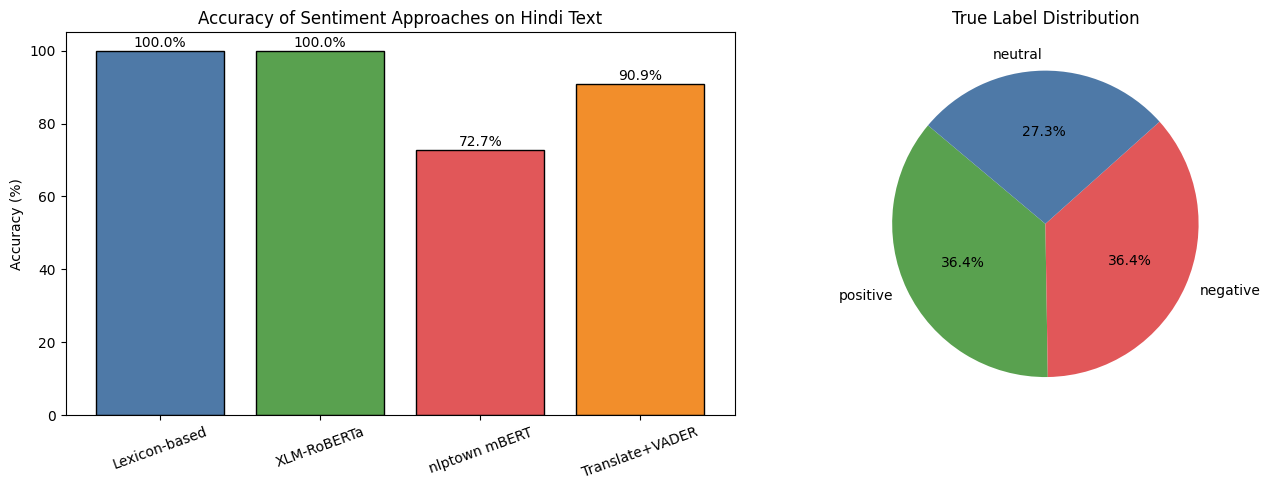

In [11]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy comparison ---
names = list(approaches.keys())
accs  = list(approaches.values())
colors = ['#4e79a7', '#59a14f', '#e15759', '#f28e2b']

axes[0].bar(names, accs, color=colors, edgecolor='black')
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy of Sentiment Approaches on Hindi Text')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

# --- Plot 2: True label distribution ---
true_labels = [s['label'] for s in hindi_sentences]
label_counts = Counter(true_labels)
axes[1].pie(
    label_counts.values(),
    labels=label_counts.keys(),
    autopct='%1.1f%%',
    colors=['#59a14f', '#e15759', '#4e79a7'],
    startangle=140
)
axes[1].set_title('True Label Distribution')

plt.tight_layout()
plt.show()

## 8. Detailed Analysis by Domain

In [12]:
# Analyse nlptown mBERT results per domain
print("NLPTOWN mBERT PREDICTIONS BY DOMAIN")
print("=" * 70)
print(f"  {'Domain':<15} {'Text (truncated)':<42} {'True':<10} {'Pred'}")
print("  " + "-" * 70)

for item, pred in zip(hindi_sentences, hindi_results):
    match_marker = '' if pred == item['label'] else ' <-- MISMATCH'
    truncated = item['text'][:39] + '...' if len(item['text']) > 39 else item['text']
    print(f"  {item['domain']:<15} {truncated:<42} {item['label']:<10} {pred}{match_marker}")

NLPTOWN mBERT PREDICTIONS BY DOMAIN
  Domain          Text (truncated)                           True       Pred
  ----------------------------------------------------------------------
  entertainment   यह फिल्म बहुत अच्छी थी, मुझे बहुत पसंद ... positive   positive
  food            इस रेस्टोरेंट का खाना स्वादिष्ट और सस्त... positive   positive
  politics        सरकार ने किसानों के लिए एक अच्छी योजना ... positive   positive
  product         यह उत्पाद बहुत गुणवत्तापूर्ण है और कीमत... positive   positive
  general         आज का मौसम बहुत सुहावना और खुशनुमा है।     positive   positive
  sports          भारतीय क्रिकेट टीम ने शानदार जीत हासिल ... positive   positive
  service         इस दुकान की सेवा बहुत अच्छी और विनम्र ह... positive   positive
  education       बच्चों की पढ़ाई में बहुत सुधार हुआ है, ... positive   negative <-- MISMATCH
  entertainment   यह फिल्म बेकार थी, समय की बर्बादी हुई।     negative   negative
  food            इस होटल का खाना बहुत खराब और महंगा था।     negative   

## 9. Interactive Sentiment Demo

In [13]:
def analyze_hindi_sentiment(text):
    """
    Run all four approaches on a given Hindi sentence and print a summary.
    """
    print(f"Text   : {text}")
    print("-" * 60)

    # Lexicon
    lex = lexicon_sentiment(text)
    print(f"  Lexicon-based   : {lex['label']:<10}  (pos={lex['pos_count']}, neg={lex['neg_count']})")

    # XLM-RoBERTa
    xlm_out = xlm_sentiment(text)[0]
    xlm_lbl = normalize_xlm_label(xlm_out['label'])
    print(f"  XLM-RoBERTa     : {xlm_lbl:<10}  (conf={xlm_out['score']:.3f})")

    # nlptown Multilingual BERT
    hb_out  = hindi_sentiment(text)[0]
    hb_lbl  = nlptown_label(hb_out['label'])
    print(f"  nlptown mBERT   : {hb_lbl:<10}  (stars={hb_out['label']}, conf={hb_out['score']:.3f})")

    # Translate + VADER
    english = translate_hi_to_en(text)
    vs  = vader.polarity_scores(english)
    vl  = vader_label(vs)
    print(f"  Translate+VADER : {vl:<10}  (compound={vs['compound']:.3f})")
    print(f"  [Translated]    : {english}")
    print()


# Demo on new sentences
demo_sentences = [
    "यह सरकार बहुत भ्रष्ट है और जनता को धोखा दे रही है।",
    "भारत का भविष्य बहुत उज्ज्वल और आशाजनक है।",
    "कल रात बारिश हुई थी।"
]

print("INTERACTIVE SENTIMENT DEMO")
print("=" * 60)
for sentence in demo_sentences:
    analyze_hindi_sentiment(sentence)

INTERACTIVE SENTIMENT DEMO
Text   : यह सरकार बहुत भ्रष्ट है और जनता को धोखा दे रही है।
------------------------------------------------------------
  Lexicon-based   : negative    (pos=0, neg=1)
  XLM-RoBERTa     : negative    (conf=0.913)
  nlptown mBERT   : negative    (stars=1 star, conf=0.650)
  Translate+VADER : negative    (compound=-0.581)
  [Translated]    : This government is very corrupt and betraying people.

Text   : भारत का भविष्य बहुत उज्ज्वल और आशाजनक है।
------------------------------------------------------------
  Lexicon-based   : neutral     (pos=0, neg=0)
  XLM-RoBERTa     : positive    (conf=0.905)
  nlptown mBERT   : positive    (stars=5 stars, conf=0.565)
  Translate+VADER : positive    (compound=0.681)
  [Translated]    : India's future is bright and promising.

Text   : कल रात बारिश हुई थी।
------------------------------------------------------------
  Lexicon-based   : neutral     (pos=0, neg=0)
  XLM-RoBERTa     : neutral     (conf=0.459)
  nlptown mBERT   :

## 10. Summary and Conclusion

### Approaches Implemented:

| Approach | Method | Key Tool |
|---|---|---|
| Lexicon-based | Word counting with negation handling | Custom Hindi lexicon |
| XLM-RoBERTa | Multilingual transformer (100 languages) | cardiffnlp/twitter-xlm-roberta |
| nlptown mBERT | Multilingual BERT, 1-5 star → label | nlptown/bert-base-multilingual-uncased-sentiment |
| Translate+VADER | Translation + English VADER | Helsinki-NLP + NLTK VADER |

### Key Observations:
- **Lexicon-based** is fast but misses context and idioms.
- **XLM-RoBERTa** was trained on tweets in 100 languages, handles Hindi social media text well.
- **nlptown mBERT** was trained on review text; gives a 1–5 star rating mapped to sentiment.
- **Translate+VADER** introduces translation errors that hurt sentiment accuracy.

### Applications:
- Social media monitoring in Indian languages
- Product review analysis in Hindi/regional languages
- News sentiment tracking
- Government feedback analysis